

# Part 2. Lifetime exposure

Functions from dem4cli for:

- GMT mapping : this is done year-to-year by matching smoothed GMT timeseries of your original simulation with target stylized GMT timeseries
- Land fraction exposed / average exceedances per year: Note - If your data is binary you will get the annual fraction of land exposed, but if it is not binary you will get the area-weighted average number of exceedances
- Lifetime exposure : per region/country, birthyear and GMT stylized pathways

To do / issues:
- add example smoothing da
- add back 'raw' RCP in le and lfe output if you pick to smooth the data? 
- region_names if subnational make them a bit more helpful! latin names not the acronyms

In [109]:
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import pickle as pk
from scipy import interpolate
import regionmask
import glob, os, re, sys
import openpyxl
import matplotlib.pyplot as plt
import warnings
from math import ceil 
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 20)
%matplotlib inline 

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append('../..') # location of dem4cli package
#import demographics4climate as dem4cli # to call them as dem4cli.function 
from dem4cli import * # to call fxns directly


In [52]:
flags

{'version': 2,
 'pop_resolution': 0.1,
 'GMT_mapping': 'year_to_year',
 'cohort_sizes_source': 'UNWPP2024',
 'countrymask': 'shapefile'}

In [53]:
bbox_europe = [ 31.99,  71.09, -14.96,  34.94]
bbox_indiaws = [ 2.00, 35.00, 66.00, 100.00 ]

## 0) Population preprocessing

See part 1 for more details: load and preprocess all demographic data (population, cohort sizes, life expectancy)

In [54]:
d_countries = preprocess_all_country_data(

    filepath_lifeexpectancy = filepath_lifeexpectancy, # life expectancy data
    start_birthyear=1950,
    end_birthyear=2025,                 # endyear is taken from end_birthyear + max life expectancy

    dir_cohortsizes = dir_cohortsizes,  # cohort size data
    data_source_cohorts='UNWPP2024',
    extend_method='linear',             # note, 'slinear' not implemented for UNWPP2024
    by_sex=False,                       # NOTE by_sex not implemented
                                            
    dir_population= dir_population,     # gridded pop data 
    ssp=2,
    urbanrural=False,                   # NOTE urbanrural not implemented for v2
    #bbox = bbox_europe,                        # could use bbox europe!!
    bbox = bbox_indiaws,

    filepath_countrymask = filepath_countrymask,    # country masks 
    data_source_countrymask = 'shapefile',
    fillcoast=False, 
    fix_smallislands=False,
    
    filepath_world_bank = filepath_world_bank_meta, # metadata 
    filepath_lookuptable = filepath_lookuptable,    # country filtering
    filter_countries=True,
    worldbank_filter=True, 
    )

    
df_countries = d_countries['info_pop']
gdf_country_borders = d_countries['borders'] 
da_regions = df_countries['region'].unique()
da_population = d_countries['population_map']
df_birthyears = d_countries['birth_years'] # NA
df_life_expectancy_5 = d_countries['life_expectancy_5']
da_cohort_size = d_countries['cohort_size']
countries_regions, countries_mask = d_countries['mask'] 

load_country_metadata took 0.04 s
load_unwpp_lifeexpectancy took 23.05 s
get_life_expectancies took 0.00 s
loading cohort sizes from UNWPP2024
load_cohort_sizes took 23.42 s
interpolate_cohortsize_countries took 0.01 s
opening compass - historical
opening compass - ssp2
load_population took 0.96 s
load_countrymask took 1.08 s
preprocess_all_country_data took 48.59 s


In [55]:
da_life_expectancy = (
    df_life_expectancy_5
    .to_xarray()
    .to_array('country')
    .rename({'Year': 'birth_year'})
    .astype(float)
)

In [56]:
df_life_expectancy_5

Country,Afghanistan,Bangladesh,Bhutan,China,India,Indonesia,Malaysia,Maldives,Myanmar,Nepal,Pakistan,Sri Lanka,Thailand
Year,,,,,,,,,,,,,
1950,54.7051,64.3785,57.9877,63.3719,64.9698,64.4966,66.4392,63.9401,62.6148,62.5044,62.6678,70.9775,64.0547
1951,54.9914,64.5367,58.0507,63.7418,65.1229,64.8597,66.9031,63.8358,62.9,62.4709,63.1308,71.3957,64.265
1952,55.3287,65.1587,58.1325,64.1075,65.192,65.2115,67.3864,63.7576,63.2916,62.495,63.5415,71.7427,64.4666
1953,55.6465,65.3259,58.2343,64.3401,65.3613,65.232,67.9438,63.7143,63.649,62.5481,63.9462,72.1706,64.6241
1954,55.9651,65.6375,58.3607,59.6083,65.6637,65.7349,68.507,63.6957,63.8958,62.719,64.333,72.5638,64.9301
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021,76.3344,82.9225,81.2563,85.5551,80.6474,78.9437,83.6094,88.1359,76.2366,78.775,78.0595,84.4865,83.8029
2022,76.441,83.1252,81.4446,85.748,80.8202,79.0574,83.7631,88.3445,76.3769,78.9434,78.1174,84.6453,83.9901
2023,76.5566,83.3198,81.6378,85.9295,80.9699,79.1701,83.9184,88.5411,76.5151,79.1097,78.1822,84.8139,84.1884


## 1) Load GMT stylized trajs

Load stylized GMT trajectories to emulate with the GMT-remapping. 

Using the options : 
- extension past 2100  with 10yrtrend (also available: 10yrmean, lastyear)
- Smoothing of first decades (OS and noOS currently not smoothed). Also available: no smoothing



In [57]:
df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS, ds_GMT_STS, df_GMT_strj = load_GMT(
    year_start=1950,
    year_end=2119,
    gmt_extend_method='10yrtrend',
    smooth_first_decades=True
)

load_GMT took 7.81 s


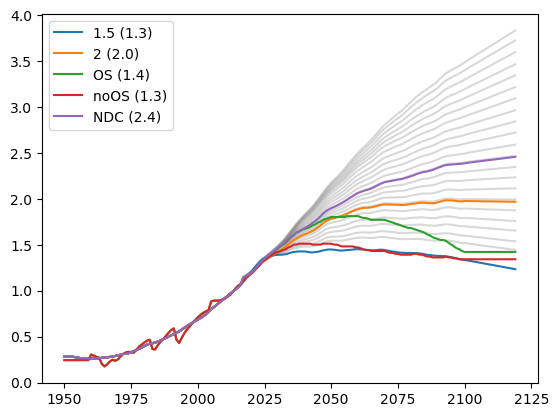

In [58]:
fig, ax = plt.subplots()

# Plot the background lines for df_GMT_strj without adding legend entries
for col in df_GMT_strj.columns:
    ax.plot(df_GMT_strj.index, df_GMT_strj[col], alpha=0.3, color='gray')  # no label

labels = ['1.5', '2', 'OS', 'noOS', 'NDC']

ax.set_prop_cycle(None)

for i, df in enumerate([df_GMT_15, df_GMT_20, df_GMT_OS, df_GMT_noOS, df_GMT_NDC]):
    labels[i] = labels[i] + ' (' + df.columns.values[0] + ')'
    df.squeeze().plot(ax=ax, label=labels[i])

plt.legend(loc='upper left')

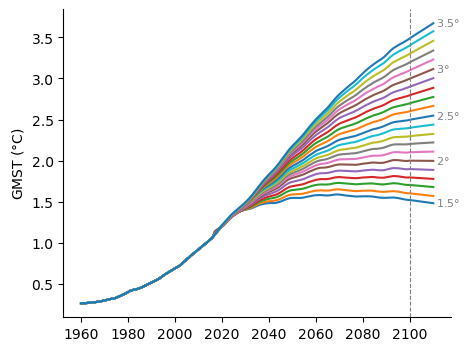

In [59]:
warminglevels = [1.5, 2, 2.5, 3, 3.5]
offsets = [-.01, 0, +.05, +.12, +.18]

fig, ax = plt.subplots(figsize=(5,4))

df_GMT_strj.loc[1960:2110].plot(ax=ax, legend=False)

ax.axvline(2100, ls='--', c='gray', lw=.8)
for lev, off in zip(warminglevels, offsets):
    ax.text(2111, lev+off, str(lev)+'$\degree$', c='gray', fontsize='8', va='center')

plt.ylabel('GMST ($\degree$C)')

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

## 2) Load climate data and GMT-mapping recipe

Equivalent of old load_isimip() function. Loads in metadata with remapping recipe based on each target trajectory, linked to each original simulation

You can account for re-baselining GMTs to a different baseline (e.g. a bias-adjustment period)



In [60]:
df_gmst = pd.read_csv(os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'))
print(df_gmst['source_id'].unique())
df_gmst

['ACCESS-CM2' 'CNRM-ESM2-1' 'CanESM5' 'EC-Earth3' 'MPI-ESM1-2-HR'
 'MRI-ESM2-0']


,Unnamed: 0,year,experiment_id,source_id,tas
0,0,1850.0,historical,ACCESS-CM2,287.007494
1,1,1850.0,historical,CNRM-ESM2-1,286.900465
2,2,1850.0,historical,CanESM5,286.806542
3,3,1850.0,historical,EC-Earth3,287.029662
4,4,1850.0,historical,MPI-ESM1-2-HR,287.064616
...,...,...,...,...,...
7525,7525,2100.0,ssp585,CNRM-ESM2-1,292.475368
7526,7526,2100.0,ssp585,CanESM5,294.452385
7527,7527,2100.0,ssp585,EC-Earth3,293.272894
7528,7528,2100.0,ssp585,MPI-ESM1-2-HR,291.375668


In [61]:
gmt_anomaly_correction = calc_gmt_anomaly_correction(
    filepath_gmst_obs=os.path.join(data_dir, 'gmst-obs/GCH_time_series_of_annual_global_temperatures_1850-2024_wrt_1991-2020.csv'),
    col='ERA5',
    gmt_anomaly_baseline_period=(1985,2014),)

gmt_anomaly_correction

# since the climate data is bias-adjusted to 1985-2014 rebaseline everything to this 

0.7432

RP implementation

In [21]:
GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

extremes="FWI95d" # e.g. "FWI95d"
model_names = GCMs
climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI' # structure should be climatedata_dir/scenario/model
filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv')
year_start=1950
year_end = 2119
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74
rolling_window=21
min_periods=11
max_diff_valid=.2

In [53]:
d_climate_data_meta = load_climate_data(
    extremes = "FWI95d",                   # e.g. "FWI95d"
    model_names = GCMs[0:2],                # GCMs : test just for two GCMs
    df_GMT_strj =df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = None,
    #climatedata_dir = '/vscmnt/brussel_pixiu_data/_data_brussel/vo/000/bvo00012/vsc10419/fwi-portugal/data/preprocessed/FWI',     # structure should be : climatedata_dir/scenario/model/'*{model}*{extreme}.nc
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    #smoothing=True,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for FWI95d


QL's implementation

In [62]:
# We will run the load_climate_data function with these arguments:

GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
extremes = "heatwavedarea" # e.g. "FWI95d", "heatwavedarea"
model_names = GCMs
GMT_extra_trajectories = [df_GMT_15, df_GMT_20, df_GMT_NDC, df_GMT_OS, df_GMT_noOS]
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']
filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv')
year_start=1950
year_end = 2119
gmt_anomaly_baseline_period = (1985,2014)
gmt_anomaly_correction = 0.74
rolling_window=21
min_periods=11
max_diff_valid=.2

In [63]:
d_climate_data_meta = load_climate_data(
    extremes = extremes,                   # e.g. "FWI95d"
    model_names = GCMs,                # GCMs : test just for two GCMs
    df_GMT_strj = df_GMT_strj ,                # stylized trajectories
    GMT_extra_trajectories = GMT_extra_trajectories,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    filepath_model_gmst = os.path.join(data_dir, 'gmst-models/gmst_models_1850_2100_fwi.csv'),
    scenarios = scenarios,
    rolling_window=21,
    min_periods=11,
    gmt_anomaly_baseline_period = (1985,2014),
    gmt_anomaly_correction = 0.74,
    year_start=1950,
    year_end = 2119,            # 2025 + max life expectancy
    gmt_mapping_method = 'year-to-year', 
    max_diff_valid = .2, 
    )

Processing climate data
Processing for heatwavedarea


In [64]:
print(d_climate_data_meta.keys())
for key, item in d_climate_data_meta.items():
    print(f"Entry {key} has keys: {list(item.keys())}")
d_climate_data_meta

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
Entry 1 has keys: ['extreme', 'model', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
Entry 2 has keys: ['extreme', 'model', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']
Entry 3 has keys: ['extreme', 'model', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff

{1: {'extreme': 'heatwavedarea',
  'model': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.05735471051576235,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
         23, 23, 23,

In [65]:
df_mapping = pd.DataFrame(data=d_climate_data_meta[1]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
df_mapping

# what index of the simulation is mapped, for all GMT levels, to each year in the scenario-GCM combination corresponding to the first dictionary entry

,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,...,2.6,2.7,2.8,2.9,3.0,3.1,3.2,3.3,3.4,3.5
1950,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1951,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1952,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1953,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
1954,23,23,23,23,23,23,23,23,23,23,...,23,23,23,23,23,23,23,23,23,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,69,72,75,78,81,84,87,91,95,100,...,130,149,149,149,149,149,149,149,149,149
2116,69,72,75,78,81,84,87,92,95,100,...,131,149,149,149,149,149,149,149,149,149
2117,69,72,75,78,81,84,87,92,95,100,...,132,149,149,149,149,149,149,149,149,149
2118,69,71,75,78,81,84,87,92,95,100,...,133,149,149,149,149,149,149,149,149,149


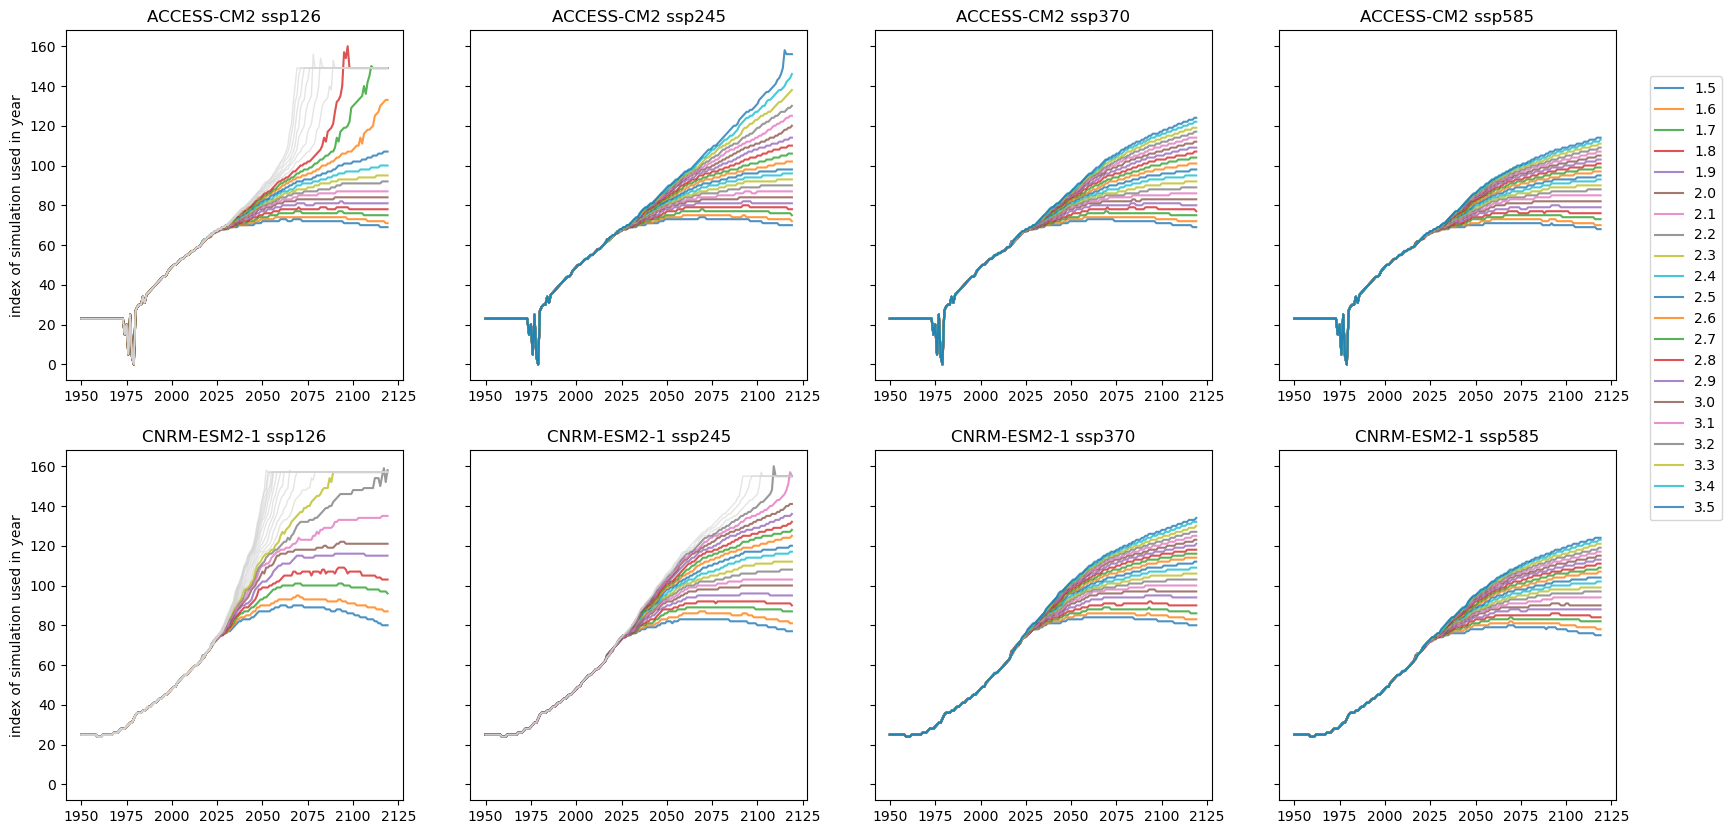

In [66]:
fig, axes = plt.subplots(2,4,figsize=(20,10),sharey=True)

axes=axes.flatten()

for i, ax in enumerate(axes):

    i+=1

    df_mapping = pd.DataFrame(data =d_climate_data_meta[i]['ind_RCP2GMT_strj'], columns=df_GMT_strj.columns, index=np.arange(1950,2120) )
    valid = np.array(d_climate_data_meta[i]['GMT_strj_valid'])  # your 0/1 array

    for col, is_valid in zip(df_mapping.columns, valid):
        if is_valid:
            ax.plot(df_mapping.index, df_mapping[col], lw=1.5, alpha=0.8,label=col)
        else:
            ax.plot(df_mapping.index, df_mapping[col], color='lightgray', lw=1.0, alpha=0.6)


    ax.set_title(d_climate_data_meta[i]['model']+' '+d_climate_data_meta[i]['scenario'])

    if i==1 or i==5:
        ax.set_ylabel('index of simulation used in year')
    
    if i==4:
        ax.legend(loc=(1.1,-.4))

    # visualize the remapping

    # gray = not valid 

## 3) Land fraction exposed

Note! If your data is BINARY this is land fraction exposed. 

If your data is not binary but is N OF EXCEEDANCES PER YEAR, then you will get the area-weighted average n of exceedances per spatial unit

In [67]:
for i in list(d_climate_data_meta.keys()):
    scenario = d_climate_data_meta[i]['scenario']
    model = d_climate_data_meta[i]['model']
    print(i, model, scenario)

# get the names / experiments of each element of the dict

# for each dict entry you have remapping recipe for each valid target trajectory 

1 ACCESS-CM2 ssp126
2 ACCESS-CM2 ssp245
3 ACCESS-CM2 ssp370
4 ACCESS-CM2 ssp585
5 CNRM-ESM2-1 ssp126
6 CNRM-ESM2-1 ssp245
7 CNRM-ESM2-1 ssp370
8 CNRM-ESM2-1 ssp585
9 CanESM5 ssp126
10 CanESM5 ssp245
11 CanESM5 ssp370
12 CanESM5 ssp585
13 EC-EARTH ssp126
14 EC-EARTH ssp245
15 EC-EARTH ssp370
16 EC-EARTH ssp585
17 MPI-ESM1-2-HR ssp126
18 MPI-ESM1-2-HR ssp245
19 MPI-ESM1-2-HR ssp370
20 MPI-ESM1-2-HR ssp585
21 MRI-ESM2-0 ssp126
22 MRI-ESM2-0 ssp245
23 MRI-ESM2-0 ssp370
24 MRI-ESM2-0 ssp585


In [93]:
d_meta_subset = dict(list(d_climate_data_meta.items())[0:1])
d_meta_subset

# test just for a subset of the simulations (faster to run)

{1: {'extreme': 'heatwavedarea',
  'model': 'ACCESS-CM2',
  'scenario': 'ssp126',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.05735471051576235,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
         23, 23, 23,

In [69]:
for key, item in d_meta_subset.items():
    print(f"Entry {key} has keys: {list(item.keys())}")

Entry 1 has keys: ['extreme', 'model', 'scenario', 'GMT', 'GMT_strj_maxdiff', 'GMT_strj_valid', 'ind_RCP2GMT_strj', 'GMT_15_maxdiff', 'GMT_15_valid', 'ind_RCP2GMT_15', 'GMT_20_maxdiff', 'GMT_20_valid', 'ind_RCP2GMT_20', 'GMT_NDC_maxdiff', 'GMT_NDC_valid', 'ind_RCP2GMT_NDC', 'GMT_OS_maxdiff', 'GMT_OS_valid', 'ind_RCP2GMT_OS', 'GMT_noOS_maxdiff', 'GMT_noOS_valid', 'ind_RCP2GMT_noOS']


In [ ]:
# Temporary: to move elsewhere

data_source = "ISIMIP"
project_phase = "isimip2b"
extreme = "heatwavedarea"
model = "hwmid99"
gcm = "hadgem2-es"
scenario = "rcp26"

#climatedata_dir = '/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data'


In [100]:
# Temporary hard-coding

d_meta_subset[1]['model'] = model
d_meta_subset[1]['scenario'] = scenario
d_meta_subset

{1: {'extreme': 'heatwavedarea',
  'model': 'hwmid99',
  'scenario': 'rcp26',
  'GMT':            tas
  1950  0.385547
  1951  0.393164
  1952  0.393677
  1953  0.379471
  1954  0.362028
  ...        ...
  2115  2.769605
  2116  2.769605
  2117  2.769605
  2118  2.769605
  2119  2.769605
  
  [170 rows x 1 columns],
  'GMT_strj_maxdiff': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]),
  'GMT_strj_valid': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]),
  'ind_RCP2GMT_strj': array([[ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         [ 23,  23,  23, ...,  23,  23,  23],
         ...,
         [ 69,  72,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149],
         [ 69,  71,  75, ..., 149, 149, 149]]),
  'GMT_15_maxdiff': 0.05735471051576235,
  'GMT_15_valid': True,
  'ind_RCP2GMT_15': array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23,
         23, 23, 23, 23,

In [88]:
#filepath_hist = glob.glob(os.path.join(climatedata_dir, data_source.lower(), project_phase.lower(), extreme, model.lower(), f'{model.lower()}_{gcm}_historical*1861_2005.nc4'))
filepath_hist = glob.glob(os.path.join(climatedata_dir, data_source.lower(), project_phase.lower(), extreme, model.lower(), f'{model.lower()}_{gcm}_historical*1861_2005.nc4'))[0]
filepath_rcp = glob.glob(os.path.join(climatedata_dir, data_source.lower(), project_phase.lower(), extreme, model.lower(), f'{model.lower()}_{gcm}_{scenario}*2006_2099.nc4'))[0]
print(filepath_hist)
print(filepath_rcp)

/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_hadgem2-es_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
/data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_hadgem2-es_rcp26_heatwavedarea_global_annual_landarea_2006_2099.nc4


In [111]:
#GCMs = ['ACCESS-CM2', 'CNRM-ESM2-1', 'CanESM5', 'EC-EARTH', 'MPI-ESM1-2-HR', 'MRI-ESM2-0']
#scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
GMT_extra_trajectories_names = ['15', '20', 'NDC', 'OS', 'noOS']

ds_lfe_perregion_perrun, ds_lfe_percountry_perrun, region_names = calc_landfraction_exposed(
    d_meta_subset, # replace with d_climate_data_meta to run all data
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    GMT_labels = df_GMT_strj.columns,
    GMT_extra_trajectories_names = GMT_extra_trajectories_names,
    year_start=1950,
    year_end=2119,
    bbox=bbox_indiaws,
    weights=None,
    areaweighted=True,
    convert_to_binary=False,            # if your data array is number of exceedances per year (not binary) you will get area-weighted average number of exceedances by default
                                        # if you set this to True your data is turned binary and you can get fraction of land area exposed to at least 1 day
    convert_to_binary_threshold=0,      # here you can change the threshold to e.g. get the fraction of land area exposed to at least X days 
    smoothing_window=21                 # window to smooth also the impact data, get only forced signal not internal variability
                                        # turn this to None for default configuration
)


# note: calling this LFE can be misleading if your data is not binary!

                         🟠 Remapping Simulation 1 of 1 🟠



IndexError: list index out of range

In [30]:
# RP's version

rename_dict = {
    i: f"{d_meta_subset[i]['model']} {d_meta_subset[i]['scenario']}"
    for i in d_meta_subset.keys()
}
rename_dict


# for plotting 

{1: 'ACCESS-CM2 ssp126'}

In [21]:
# QL's version

rename_dict = {
    i: " ".join(["hadgem2-es (h-c)", "rcp60 (hc)"])
    for i in d_meta_subset.keys()
}

rename_dict

{1: 'hadgem2-es (h-c) rcp60 (hc)'}

In [22]:
print(ds_lfe_perregion_perrun.region)
print(region_names)

<xarray.DataArray 'region' (region: 6)>
array([0, 1, 2, 3, 4, 5])
Coordinates:
  * region   (region) int64 0 1 2 3 4 5
['South Asia' 'East Asia & Pacific' 'Low income' 'Lower middle income'
 'Upper middle income' 'World']


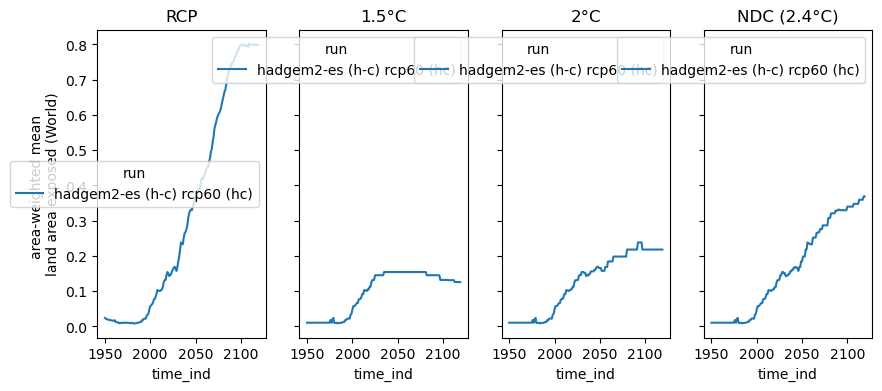

In [23]:

fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

ds_lfe_perregion_perrun.sel(region=5)['landfrac_peryear_perregion_RCP'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[0])
ds_lfe_perregion_perrun.sel(region=5)['landfrac_peryear_perregion_15'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[1])
ds_lfe_perregion_perrun.sel(region=5)['landfrac_peryear_perregion_20'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[2])
ds_lfe_perregion_perrun.sel(region=5)['landfrac_peryear_perregion_NDC'].to_pandas().T.rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])
    ax.set_xticklabels([int(t + year_start) for t in ax.get_xticks()])

axes[0].set_ylabel(f'area-weighted mean \nland area exposed ({region_names[5]})');


## 4) Lifetime exposure 

Lifetime exposure per run, and aggregated across runs ("multi-model") for original RCP and for target trajectories after remapping. 

also outputs region names and population-weighted average life-expectancy per region (should this be weighted by cohort aged 0 or total population?? - Ask Emma)



In [24]:
ds_le_percountry_perrun, ds_le_perregion_perrun, region_names, da_life_expectancy_perregion = calc_lifetime_exposure(
   d_meta_subset, 
    df_countries, 
    countries_regions, 
    countries_mask, 
    climatedata_dir,
    da_population, 
    df_life_expectancy_5,
    da_cohort_size,
    GMT_labels=df_GMT_strj.columns , 
    GMT_extra_trajectories_names=GMT_extra_trajectories_names,
    start_birthyear=1950,
    end_birthyear=2025,
    year_start=1950,
    year_end=2119,
    bbox=bbox_indiaws,
    smoothing_window=21   
    )



                         🟠 Remapping Simulation 1 of 1 🟠

Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_hadgem2-es_historical_heatwavedarea_global_annual_landarea_1861_2005.nc4
Loading /data/brussel/vo/000/bvo00012/vsc11137/source2suffering/data/isimip/isimip2b/heatwavedarea/hwmid99/hwmid99_hadgem2-es_rcp60_heatwavedarea_global_annual_landarea_2006_2099.nc4
load_climate_data_array took 0.21 s
⏳ Computing the Population-Weighted Spatial Average of the Exposure for all countries

⏳ Computing the Population-Weighted Spatial Average of the Exposure for all regions

🟢 Population-Weighted Spatial Average of the Exposure for all countries and regions Computed
Computing lifetime exposure (LE) for RCP 

Computing lifetime exposure (LE) for 15 

Computing lifetime exposure (LE) for 20 

Computing lifetime exposure (LE) for NDC 

Computing lifetime exposure (LE) for OS 

Computing lifetime exposure (LE) for noOS 

Computing life

In [25]:
# For each country and model run, this dataset gives the cumulated number of years a typical person from each birth cohort is or will be affected by a heatwave.

ds_le_percountry_perrun

<xarray.Dataset>
Dimensions:                    (run: 1, country: 13, birth_year: 76, GMT: 21)
Coordinates:
  * run                        (run) int64 1
  * country                    (country) object 'Afghanistan' ... 'Thailand'
  * birth_year                 (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                        (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_percountry_perrun_RCP   (run, country, birth_year) float64 0.2694 ... ...
    le_percountry_perrun_15    (run, country, birth_year) float64 0.283 ... 2...
    le_percountry_perrun_20    (run, country, birth_year) float64 0.283 ... 2...
    le_percountry_perrun_NDC   (run, country, birth_year) float64 0.283 ... 3...
    le_percountry_perrun_OS    (run, country, birth_year) float64 0.2917 ... ...
    le_percountry_perrun_noOS  (run, country, birth_year) float64 0.2917 ... ...
    le_percountry_perrun_strj  (run, country, birth_year, GMT) float64 0.283 ...

In [26]:
ds_le_perregion_perrun

<xarray.Dataset>
Dimensions:                   (run: 1, region: 6, birth_year: 76, GMT: 21)
Coordinates:
  * run                       (run) int64 1
  * region                    (region) int64 0 1 2 3 4 5
  * birth_year                (birth_year) int64 1950 1951 1952 ... 2024 2025
  * GMT                       (GMT) float64 1.5 1.6 1.7 1.8 ... 3.2 3.3 3.4 3.5
Data variables:
    le_perregion_perrun_RCP   (run, region, birth_year) float64 2.49 ... 36.26
    le_perregion_perrun_15    (run, region, birth_year) float64 2.113 ... 12.79
    le_perregion_perrun_20    (run, region, birth_year) float64 2.113 ... 14.82
    le_perregion_perrun_NDC   (run, region, birth_year) float64 2.113 ... 19.46
    le_perregion_perrun_OS    (run, region, birth_year) float64 2.147 ... 12.93
    le_perregion_perrun_noOS  (run, region, birth_year) float64 2.147 ... 12.53
    le_perregion_perrun_strj  (run, region, birth_year, GMT) float64 2.113 .....

In [27]:
region_names

array(['South Asia', 'East Asia & Pacific', 'Low income',
       'Lower middle income', 'Upper middle income', 'World'],
      dtype=object)

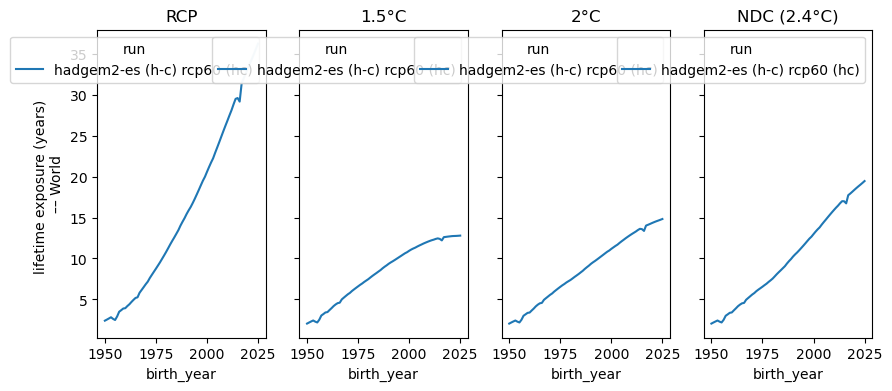

In [31]:
fig, axes = plt.subplots(1,4,sharey=True,figsize=(10,4))

(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_RCP'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[0])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_15'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[1])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_20'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[2])
(ds_le_perregion_perrun.sel(region=5)['le_perregion_perrun_NDC'].to_pandas().T).rename(columns=rename_dict).plot(ax=axes[3])

labels = ['RCP', '1.5°C', '2°C',  'NDC (2.4°C)',]

for i,ax in enumerate(axes):
    ax.set_title(labels[i])

axes[0].set_ylabel(f'lifetime exposure (years) \n–– {region_names[5]}');


# TODO: run for all simulations and see! 

## 5) aggregation function

Median, mean and spread across 'runs' i.e. across remapped / synthetic trajectories

In [32]:
#  area-weighted average (i.e. land fraction exposed if binary)


ds_lfe_perregion_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_perregion_perrun,
    GMT_extra_trajectories_names,
    )



Computing the MMM and stats for each region


In [33]:
# lifetime exposure 

ds_le_perregion_mmm = calc_lifetime_exposure_mmm(
    ds_le_perregion_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each region


In [34]:

ds_lfe_percountry_mmm = calc_landfraction_exposed_mmm(
    ds_lfe_percountry_perrun,
    GMT_extra_trajectories_names,
    )


Computing the MMM and stats for each country


In [35]:
ds_le_percountry_mmm = calc_lifetime_exposure_mmm(
    ds_le_percountry_perrun,
    GMT_extra_trajectories_names,
    year_ref=1950
    )


Computing the MMM and stats for each country


## 6) Plots

In [36]:
region_names

# Note that World = all countries/area included in your bounding box 

array(['South Asia', 'East Asia & Pacific', 'Low income',
       'Lower middle income', 'Upper middle income', 'World'],
      dtype=object)

Text(0.5, 1.0, 'World')

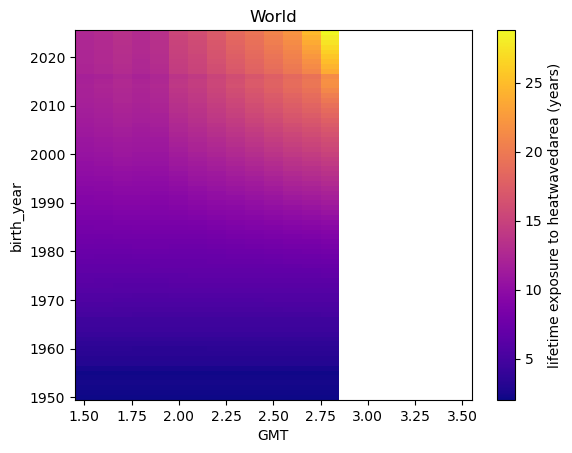

In [ ]:
# plot heatmap from median of remapped trajectories (units:years exposed)

(ds_le_perregion_mmm['median_strj']).sel(region=5).plot(
    cbar_kwargs={'label': f"lifetime exposure to {extremes} (years)"},
    cmap='plasma'
    )

plt.title(region_names[5])


Text(0.5, 1.0, 'World')

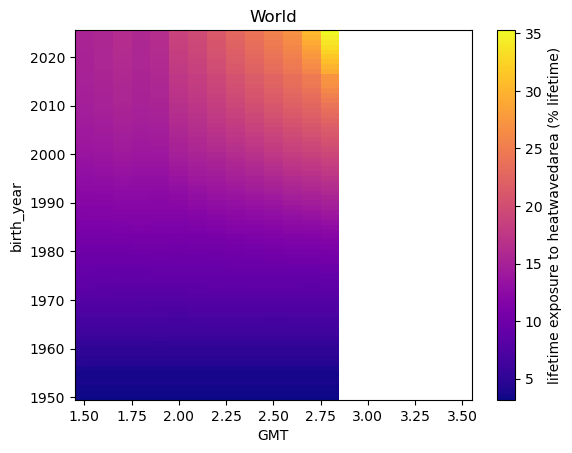

In [39]:
# plot % lifetime exposed 

(((ds_le_perregion_mmm['median_strj']) / da_life_expectancy_perregion)*100).sel(region=5).plot(
    cbar_kwargs={'label': f"lifetime exposure to {extremes} (% lifetime)"},
    cmap='plasma'
    )

plt.title(region_names[5])



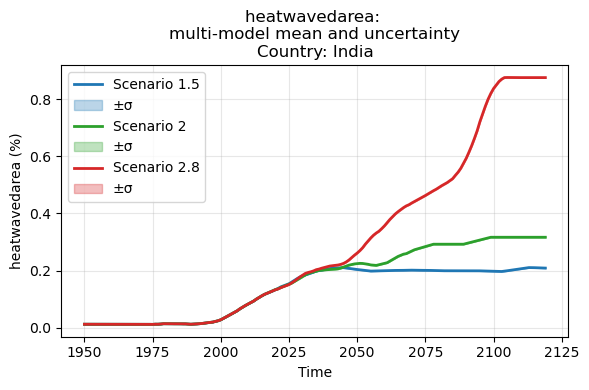

In [42]:
# timeseries area-weighted average


# === Parameters ===
country_name = 'India'  # <-- change the country here
year_range = np.arange(1950, 1950+len(ds_lfe_percountry_mmm.time_ind))  # x-axis: birth years

# === Define the scenarios to plot ===
GMTs = 1.5, 2, 2.8
colors = {0: 'tab:blue', 1: 'tab:green', 2: 'tab:red'}

# === Create the figure ===
plt.figure(figsize=(6,4))

for i,scen in enumerate(GMTs):
    # Extract multi-model mean and standard deviation for this scenario
    mmm = ds_lfe_percountry_mmm[f'mmm_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean() # this is mmm_strj smoothed with .rolling(time_ind=10, center=True, min_periods=1).mean()
    std = ds_lfe_percountry_mmm[f'std_strj'].sel(country=country_name, GMT=scen).rolling(time_ind=10,min_periods=1).mean()
    
    # Plot the mean
    plt.plot(
        year_range, 
        mmm, 
        label=f'Scenario {scen}', 
        color=colors[i],
        lw=2
    )
    
    # Plot the uncertainty range (±σ/2)
    plt.fill_between(
        year_range,
        mmm - std,
        mmm + std ,
        alpha=0.3,
        label=rf'±σ',
        color=colors[i],
        lw=1
    )

# === Customize the plot ===
plt.title(f"{extremes}: \nmulti-model mean and uncertainty\nCountry: {country_name}")
plt.xlabel("Time")
plt.ylabel(f"{extremes} (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



0.28301772082177923 7.722844577953216
2.7335924807041883 55.33947711992264
9.529330554699897 79.88537731933594


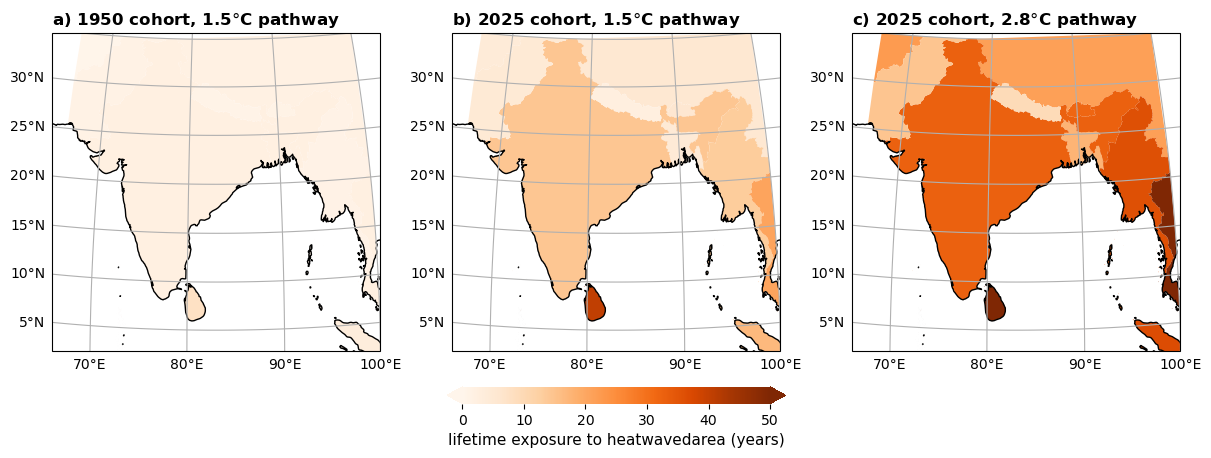

In [44]:
# map : South Asia, country level results



# -------------------- Parameters -------------------- #
GMTs = [1.5, 1.5, 2.8]
birth_years = [1950,2025,2025]
titles = ['a)', 'b)', 'c)']

use_log_scale = False

vmin=0
vmax=50

cmap = plt.cm.Oranges # or OrRd

# -------------------- Projections ---------- #

central_lon, central_lat = 83, 18.5
extent = [66, 100, 2, 35]

proj = ccrs.Orthographic(central_lon, central_lat)

# -------------------- Plot -------------------- #

fig, axes = plt.subplots(1,3, figsize=(12,8),subplot_kw={'projection': proj},  layout='constrained')


for ax, birth_year, GMT, title in zip(axes.flatten(), birth_years, GMTs, titles):


    # -------------------- Extract values from ds_le_percountry -------------------- #
    # Multi-model mean for the selected scenario
    le_mean = ds_le_percountry_mmm[f'mmm_strj'].sel(birth_year=birth_year, GMT=GMT) # for % lfietime  / da_life_expectancy * 100

    # Convert to DataFrame
    df_values = le_mean.to_dataframe(name='mean_val').reset_index()

    # -------------------- Merge with country borders -------------------- #
    gdf_plot = gdf_country_borders.reset_index().merge(
        df_values, left_on='name', right_on='country', how='left'
    )

    gdf_plot.to_crs(proj).plot(
    ax=ax,
    column='mean_val',
    cmap=cmap,
    legend=False,
    legend_kwds={'shrink': 0.5},
    missing_kwds={'color': 'lightgrey'},
    vmin=vmin,vmax=vmax
    )

    ax.set_title(title+f' {birth_year} cohort, {GMT}$\degree$C pathway', loc='left', fontweight='bold')
    ax.set_extent(extent)
    gl = ax.gridlines( draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False
    ax.coastlines(resolution='50m')

    print(gdf_plot['mean_val'].min(), gdf_plot['mean_val'].max())

# colorbar 
foo = ax.collections[0]
cbar_lab = f'lifetime exposure to {extremes} (years)'
cbar = fig.colorbar(foo, extend='both', ax=axes[0:3], location='bottom',shrink=0.3, fraction=0.08, pad=0.02)
cbar.set_label(label=cbar_lab,size=11)
cbar.outline.set_edgecolor('none')
